# Explicit U-Net segmentation score

A one-level U-Net-like network learns a synthetic bright-square foreground task. This is not the original U-Net implementation or a medical model. Attribution targets the **mean foreground logit inside a fixed central ROI**, not a predicted mask or whole-image class. Changing the ROI changes the question. Reference: [Ronneberger et al. (2015)](https://arxiv.org/abs/1505.04597).

Offline CPU tutorial. Fixed seeds and two PyTorch threads; small synthetic data only.


In [1]:
import os, sys, time, resource, json
from pathlib import Path
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
root = Path.cwd()
if not (root / "src").is_dir():
    root = root.parent
sys.path.insert(0, str(root / "src"))
import numpy as np
import torch
from torch import nn
torch.set_num_threads(2)
torch.set_num_interop_threads(2)
torch.manual_seed(7)
np.random.seed(7)
started = time.perf_counter()
print("CPU only; torch", torch.__version__, "threads", torch.get_num_threads())



CPU only; torch 2.10.0.dev20251025+cpu threads 2


Held-out foreground IoU: 0.9702970385551453
ROI foreground score: [[6.5003437995910645, -8.582688331604004]]


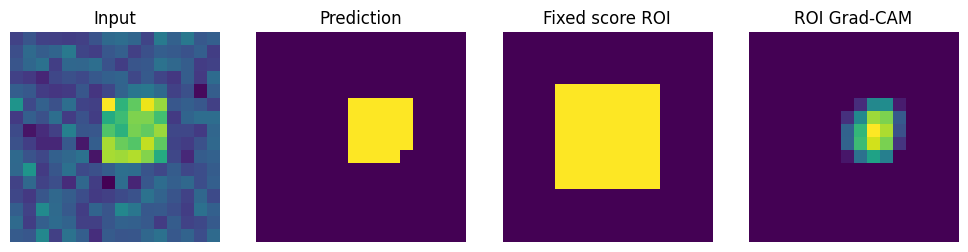

In [2]:
from autoexplain.toys import TinyUNet
from autoexplain.adapters import SegmentationScoreAdapter
from autoexplain.core import Inspector
def squares(count, seed):
    g = torch.Generator().manual_seed(seed)
    masks = torch.zeros(count, 16, 16, dtype=torch.long)
    for i in range(count):
        y, x = torch.randint(2, 10, (2,), generator=g).tolist()
        masks[i, y:y+5, x:x+5] = 1
    images = masks[:, None].float() + 0.15 * torch.randn(count, 1, 16, 16, generator=g)
    return images, masks
model = TinyUNet()
images, masks = squares(24, 12)
optimizer = torch.optim.Adam(model.parameters(), lr=0.02)
for _ in range(35):
    optimizer.zero_grad()
    loss = nn.functional.cross_entropy(model(images), masks)
    loss.backward(); optimizer.step()
model.eval()
test, truth = squares(4, 90)
with torch.no_grad():
    pred = model(test).argmax(1)
    intersection = ((pred == 1) & (truth == 1)).sum()
    union = ((pred == 1) | (truth == 1)).sum()
print("Held-out foreground IoU:", (intersection / union.clamp_min(1)).item())
roi = torch.zeros(16, 16); roi[4:12, 4:12] = 1
adapter = SegmentationScoreAdapter(model, roi)
inspector = Inspector(adapter)
gradient = inspector.input_gradients(test[:1], target=1)
cam = inspector.gradcam(test[:1], layer="model.decoder.0", target=1)
assert adapter(test).shape == (4, 2)
assert gradient.shape == (1, 1, 16, 16) and cam.shape == (1, 16, 16)
print("ROI foreground score:", adapter(test[:1]).detach().tolist())
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(10, 2.5))
for ax, data, title in zip(axes, [test[0,0], pred[0], roi, cam[0]],
                          ["Input", "Prediction", "Fixed score ROI", "ROI Grad-CAM"]):
    ax.imshow(data); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()



In [3]:
elapsed = time.perf_counter() - started
rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
# Linux reports KiB; macOS reports bytes. This is this kernel's lifetime high-water mark.
peak_mib = rss / (1024 * 1024 if sys.platform == "darwin" else 1024)
print(json.dumps({"tutorial_compute_wall_seconds": round(elapsed, 3),
                  "kernel_lifetime_peak_rss_mib": round(peak_mib, 2),
                  "memory_scope": "kernel process only; includes imports; excludes child processes"}))



{"tutorial_compute_wall_seconds": 0.913, "kernel_lifetime_peak_rss_mib": 406.04, "memory_scope": "kernel process only; includes imports; excludes child processes"}
